In [7]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')

In [1]:
import sys
sys.path.append('/workspaces/BlizzardX')

In [8]:
from src.Model.feature_engineering import FeatureEngineering , ColdEventDetector
fe=FeatureEngineering(df)
ce =ColdEventDetector(fe.apply_all_features())

In [9]:
df=ce.apply_cold_event_detection()

In [10]:
df

,DATE,Station_ID,LATITUDE,LONGITUDE,ELEVATION,NAME,Season,TMIN,TMAX,PRCP,...,Snowfall_Intensity,SNWD_Snowfall_Diff,PRCP_Lag1,PRCP_Lag2,Cumulative_Precipitation_7,Rolling_Sum_PRCP_14,TMAX_PRCP_Interaction,TMIN_SNOW_Interaction,PRCP_SNOW_Interaction,Cold_Event
0,2008-07-01,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,15.60,28.3,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
1,2008-07-02,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,15.60,30.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
2,2008-07-03,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,12.80,27.8,8.10,...,0.00,0.00,0.00,0.00,8.10,8.10,225.18,0.00,0.00,1
3,2008-07-04,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,16.10,30.6,16.30,...,0.00,0.00,8.10,0.00,24.40,24.40,498.78,0.00,0.00,0
4,2008-07-05,USC00272302,42.8267,-71.6261,73.2,NH E MILFORD,Summer,16.10,22.8,0.00,...,0.00,0.00,16.30,8.10,24.40,24.40,0.00,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53881,2025-04-11,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-13.90,-6.1,1.00,...,0.08,151.92,0.50,13.20,32.00,92.85,-6.10,-180.70,13.00,0
53882,2025-04-12,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-11.67,-4.8,1.43,...,0.10,151.90,1.00,0.50,33.43,84.88,-6.86,-178.90,21.92,0
53883,2025-04-13,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-9.43,-3.5,1.87,...,0.12,151.88,1.43,1.00,19.30,83.15,-6.54,-166.63,33.04,0
53884,2025-04-14,USW00014755,44.2703,-71.3033,1911.7,NH MT WASHINGTON,Spring,-7.20,-2.2,2.30,...,0.13,151.87,1.87,1.43,20.60,71.25,-5.06,-144.00,46.00,0


In [11]:
df.to_csv('/workspaces/BlizzardX/Data/feature_data.csv', index=False)

In [12]:
df[df['Cold_Event'] == 1]['Cold_Event'].count(),df[df['Cold_Event'] == 0]['Cold_Event'].count()

(12348, 41538)

In [10]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

In [13]:
# Step 1: Import the class
from src.Model.prophet_model import ProphetForecaster

# Step 2: Create an instance of the forecaster
forecaster = ProphetForecaster(data_path="/workspaces/BlizzardX/Data/feature_data.csv")

# Step 3: Load and preprocess the data
forecaster.load_and_prepare_data()

# Step 4: Train models on all stations
results_df = forecaster.run_all_stations()

# Step 5: View results
print(results_df.head())


Processing Station: USW00014755
Processing Station: USC00278614
Processing Station: USC00279278
Processing Station: USC00272302


01:11:54 - cmdstanpy - INFO - Chain [1] start processing
01:11:54 - cmdstanpy - INFO - Chain [1] start processing
01:11:54 - cmdstanpy - INFO - Chain [1] start processing
01:11:54 - cmdstanpy - INFO - Chain [1] done processing
01:11:55 - cmdstanpy - INFO - Chain [1] done processing
01:11:55 - cmdstanpy - INFO - Chain [1] done processing
01:11:56 - cmdstanpy - INFO - Chain [1] start processing
01:11:57 - cmdstanpy - INFO - Chain [1] start processing
01:11:57 - cmdstanpy - INFO - Chain [1] done processing
01:11:58 - cmdstanpy - INFO - Chain [1] start processing
01:11:59 - cmdstanpy - INFO - Chain [1] done processing
01:11:59 - cmdstanpy - INFO - Chain [1] start processing
01:12:00 - cmdstanpy - INFO - Chain [1] done processing
01:12:01 - cmdstanpy - INFO - Chain [1] start processing
01:12:01 - cmdstanpy - INFO - Chain [1] start processing
01:12:01 - cmdstanpy - INFO - Chain [1] done processing
01:12:01 - cmdstanpy - INFO - Chain [1] done processing
01:12:02 - cmdstanpy - INFO - Chain [1]

Processing Station: USC00275703


01:13:58 - cmdstanpy - INFO - Chain [1] start processing
01:13:59 - cmdstanpy - INFO - Chain [1] done processing
01:13:59 - cmdstanpy - INFO - Chain [1] start processing
01:14:01 - cmdstanpy - INFO - Chain [1] done processing
01:14:01 - cmdstanpy - INFO - Chain [1] done processing
01:14:01 - cmdstanpy - INFO - Chain [1] start processing
01:14:02 - cmdstanpy - INFO - Chain [1] done processing
01:14:02 - cmdstanpy - INFO - Chain [1] start processing
01:14:04 - cmdstanpy - INFO - Chain [1] start processing
01:14:04 - cmdstanpy - INFO - Chain [1] start processing
01:14:04 - cmdstanpy - INFO - Chain [1] done processing
01:14:05 - cmdstanpy - INFO - Chain [1] start processing
01:14:06 - cmdstanpy - INFO - Chain [1] done processing
01:14:06 - cmdstanpy - INFO - Chain [1] start processing
01:14:06 - cmdstanpy - INFO - Chain [1] done processing
01:14:07 - cmdstanpy - INFO - Chain [1] done processing
01:14:07 - cmdstanpy - INFO - Chain [1] start processing
01:14:08 - cmdstanpy - INFO - Chain [1]

    Station_ID                                        Best_Params  \
0  USC00272302  {'changepoint_prior_scale': 0.001, 'seasonalit...   
1  USC00279278  {'changepoint_prior_scale': 0.001, 'seasonalit...   
2  USC00278614  {'changepoint_prior_scale': 0.1, 'seasonality_...   
3  USC00275703  {'changepoint_prior_scale': 0.1, 'seasonality_...   
4  USW00014755  {'changepoint_prior_scale': 0.1, 'seasonality_...   

   Validation_MAE  Test_MAE  Test_RMSE  Test_MAPE  Test_SMAPE  Test_Samples  
0        0.061543  0.775399   0.938718  24.458512   25.864945           105  
1        0.058079  0.761217   0.941455  23.463409   35.785729           105  
2        0.061566  0.934974   1.136046  21.802992   26.779494           105  
3        0.079660  1.065415   1.338553  35.151303   33.871400           105  
4        0.041092  0.651074   0.809263   6.702768    6.184956           105  



📈 Forecast Results for Station USC00272302 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -1.7  -2.35       -3.53       -1.10
2025-01-02   0.6  -0.36       -1.50        0.79
2025-01-03  -1.1  -1.05       -2.14        0.11
2025-01-04  -6.1  -5.63       -6.70       -4.49
2025-01-05  -6.1  -6.63       -7.83       -5.54
2025-01-06 -10.6 -10.82      -11.95       -9.78
2025-01-07 -10.6  -9.97      -11.12       -8.81
2025-01-08  -8.9  -7.42       -8.54       -6.36
2025-01-09 -10.0  -8.91      -10.06       -7.74
2025-01-10  -8.3  -7.77       -9.00       -6.55
2025-01-11  -8.3  -7.56       -8.68       -6.43
2025-01-12 -10.6 -11.79      -12.88      -10.65
2025-01-13 -10.0 -12.83      -13.93      -11.68
2025-01-14  -9.4 -10.94      -12.11       -9.75
2025-01-15  -7.8  -7.04       -8.23       -5.87
2025-01-16 -15.0 -14.36      -15.56      -13.18
2025-01-17 -15.0 -14.04      -15.21      -12.91
2025-01-18 -13.3 -13.79      -14.85      -12.58
2025-01-19  -5.6  -6.71       -

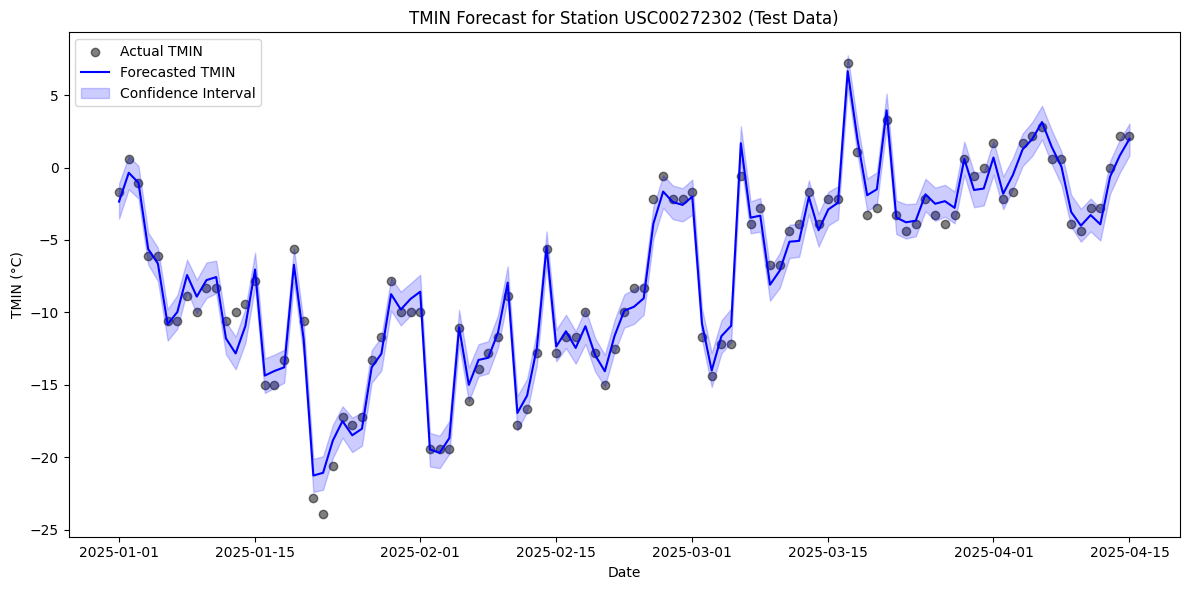


📈 Forecast Results for Station USC00279278 (Test Data):
        ds      y   yhat  yhat_lower  yhat_upper
2025-01-01  -1.10  -1.86       -2.94       -0.75
2025-01-02   1.10   0.10       -1.01        1.18
2025-01-03  -1.10   0.00       -1.07        1.12
2025-01-04  -4.40  -3.63       -4.78       -2.51
2025-01-05  -7.20  -7.06       -8.09       -5.91
2025-01-06 -10.60 -10.53      -11.73       -9.38
2025-01-07 -10.60 -10.40      -11.60       -9.29
2025-01-08  -8.30  -7.29       -8.49       -6.13
2025-01-09 -10.60  -9.65      -10.70       -8.51
2025-01-10  -8.30  -8.84       -9.91       -7.74
2025-01-11  -5.60  -5.78       -6.89       -4.64
2025-01-12  -6.70  -8.90       -9.94       -7.74
2025-01-13  -8.30 -11.52      -12.64      -10.41
2025-01-14  -8.30  -9.68      -10.74       -8.58
2025-01-15  -7.20  -6.22       -7.41       -5.14
2025-01-16 -14.40 -13.66      -14.82      -12.53
2025-01-17 -12.80 -11.85      -12.87      -10.71
2025-01-18 -10.00 -10.12      -11.25       -9.03
2025-01-19  

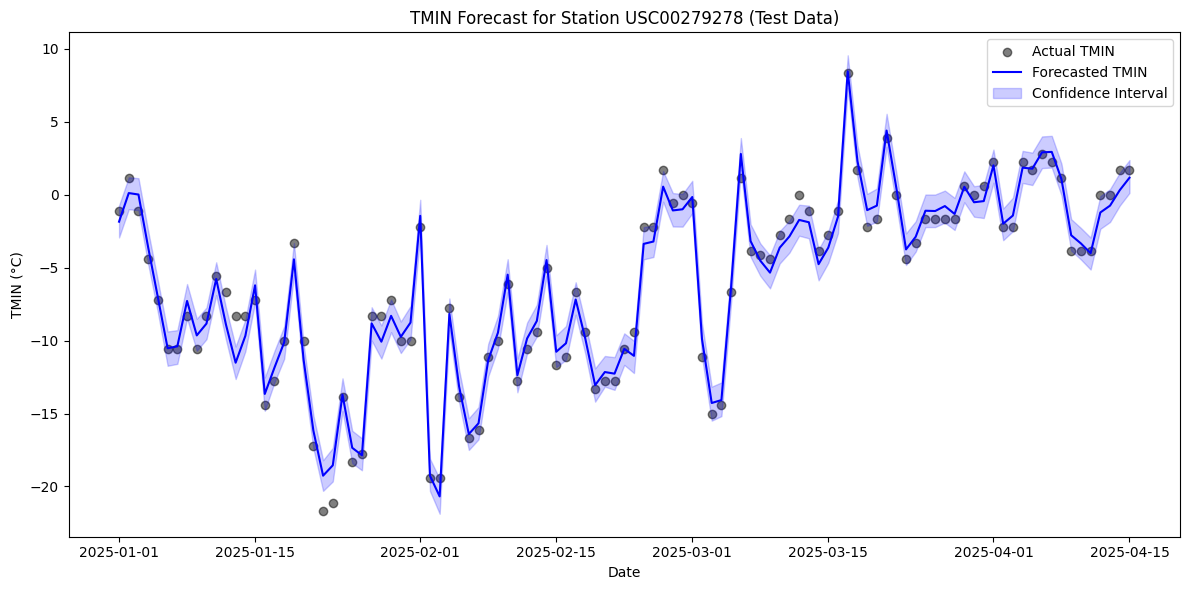


📈 Forecast Results for Station USC00278614 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -2.8  -5.01       -6.16       -3.88
2025-01-02   0.6  -1.09       -2.26        0.11
2025-01-03  -2.2  -2.30       -3.50       -1.08
2025-01-04  -7.8  -7.80       -8.96       -6.63
2025-01-05  -8.3  -9.83      -10.95       -8.60
2025-01-06 -13.9 -14.97      -16.13      -13.69
2025-01-07 -12.8 -13.73      -14.92      -12.55
2025-01-08  -8.9  -8.05       -9.20       -6.93
2025-01-09 -10.6  -9.83      -10.89       -8.64
2025-01-10  -8.3  -8.95      -10.10       -7.84
2025-01-11  -6.7  -6.31       -7.52       -5.11
2025-01-12 -10.0 -11.60      -12.70      -10.41
2025-01-13 -10.0 -13.22      -14.33      -12.03
2025-01-14  -9.4 -10.84      -11.98       -9.71
2025-01-15  -7.8  -7.07       -8.30       -5.89
2025-01-16 -17.2 -16.28      -17.47      -15.12
2025-01-17 -17.2 -15.62      -16.74      -14.34
2025-01-18 -13.3 -12.21      -13.40      -10.97
2025-01-19  -5.0  -4.53       -

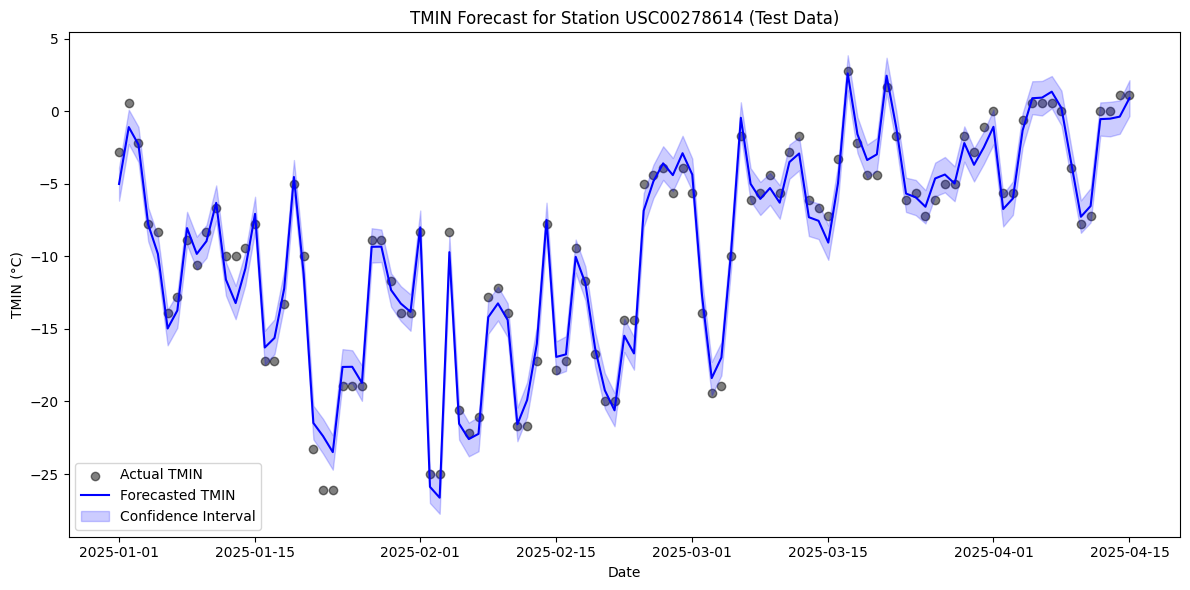


📈 Forecast Results for Station USC00275703 (Test Data):
        ds     y   yhat  yhat_lower  yhat_upper
2025-01-01  -2.2  -3.59       -5.09       -1.98
2025-01-02   0.6  -0.32       -1.93        1.16
2025-01-03  -1.7  -2.78       -4.35       -1.23
2025-01-04  -7.8  -9.57      -11.11       -7.97
2025-01-05  -6.7  -8.81      -10.44       -7.37
2025-01-06 -10.6 -10.39      -11.94       -8.93
2025-01-07 -11.7 -10.09      -11.61       -8.60
2025-01-08 -10.6  -7.38       -8.92       -5.76
2025-01-09 -11.1  -9.02      -10.44       -7.48
2025-01-10  -8.9  -9.31      -10.73       -7.90
2025-01-11  -6.7  -6.56       -8.07       -5.05
2025-01-12 -10.0 -11.45      -12.91       -9.85
2025-01-13 -10.6 -13.13      -14.65      -11.58
2025-01-14 -11.1 -11.18      -12.76       -9.70
2025-01-15  -7.8  -6.86       -8.43       -5.35
2025-01-16 -16.1 -14.95      -16.47      -13.42
2025-01-17 -16.1 -14.76      -16.34      -13.19
2025-01-18 -12.8 -12.79      -14.27      -11.13
2025-01-19  -4.4  -5.38       -

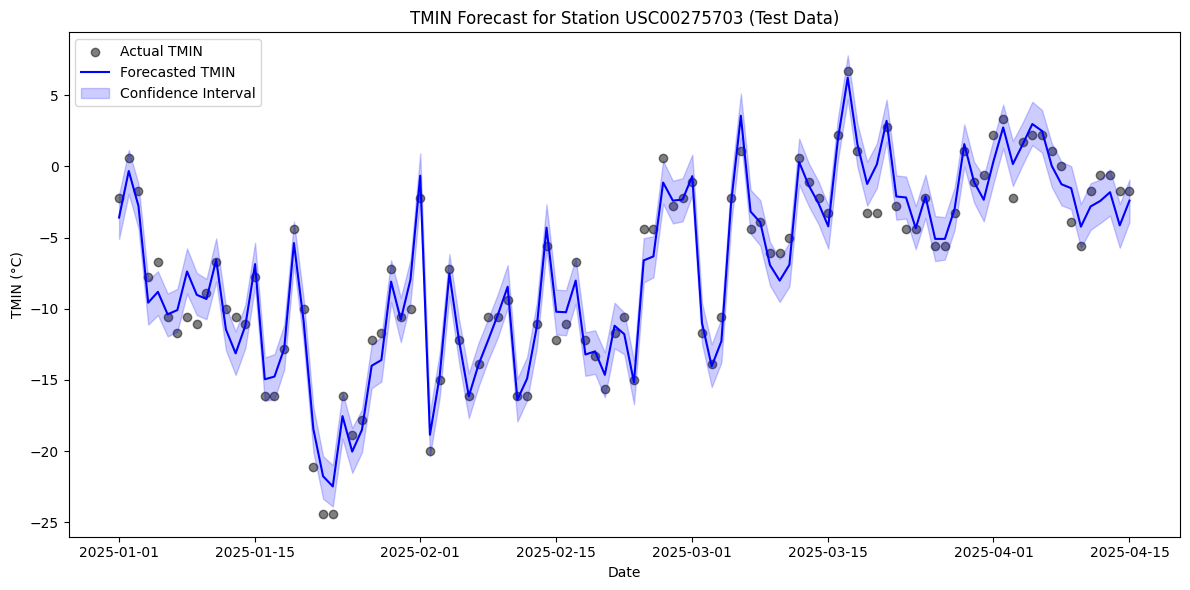


📈 Forecast Results for Station USW00014755 (Test Data):
        ds      y   yhat  yhat_lower  yhat_upper
2025-01-01  -7.20  -8.03       -8.80       -7.23
2025-01-02 -13.90 -14.20      -14.97      -13.45
2025-01-03 -17.80 -19.28      -20.08      -18.46
2025-01-04 -23.30 -24.51      -25.29      -23.76
2025-01-05 -23.90 -23.69      -24.51      -22.93
2025-01-06 -13.90 -14.34      -15.13      -13.57
2025-01-07 -24.40 -23.87      -24.64      -23.05
2025-01-08 -23.90 -22.86      -23.65      -22.00
2025-01-09 -24.40 -24.25      -25.03      -23.46
2025-01-10 -17.80 -17.45      -18.24      -16.69
2025-01-11 -11.70 -11.44      -12.26      -10.74
2025-01-12 -16.70 -17.30      -18.10      -16.52
2025-01-13 -13.30 -14.65      -15.43      -13.86
2025-01-14 -16.10 -16.57      -17.40      -15.79
2025-01-15 -22.20 -21.84      -22.65      -21.09
2025-01-16 -22.20 -21.07      -21.90      -20.30
2025-01-17 -20.00 -19.01      -19.83      -18.20
2025-01-18 -16.10 -16.04      -16.79      -15.23
2025-01-19 -

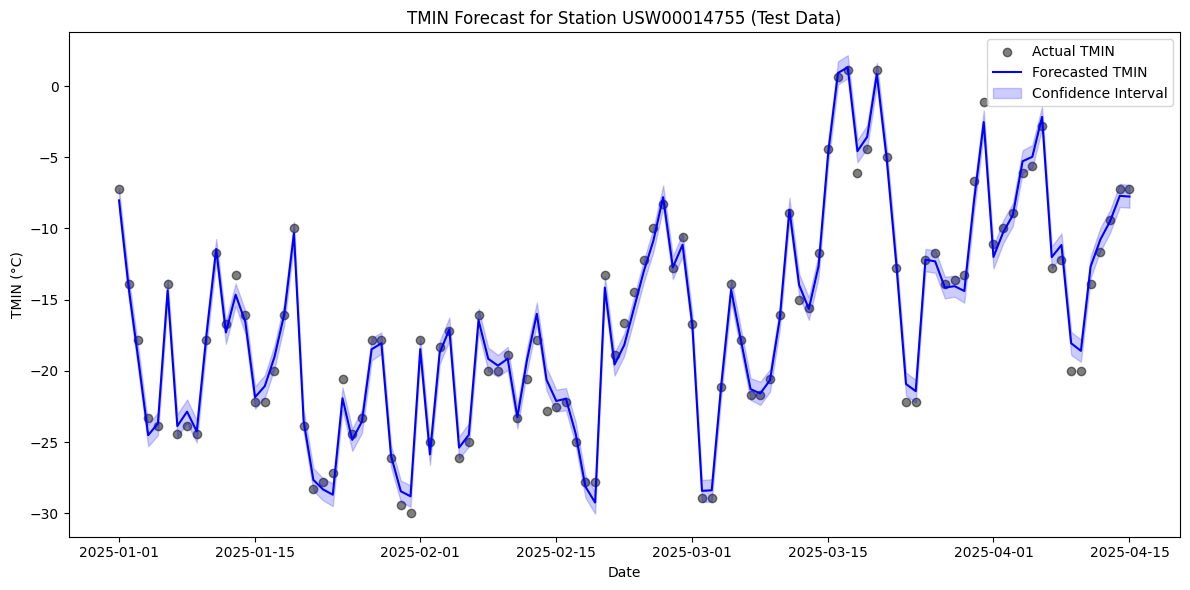

In [14]:
for station in ["USC00272302","USC00279278","USC00278614","USC00275703","USW00014755"]:
    forecaster.plot_station_forecast(station)

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Input
import keras_tuner as kt
from keras_tuner import Objective
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load and filter data
data = pd.read_csv('/workspaces/BlizzardX/Data/feature_data.csv')
station_id = 'USC00279278'
data = data[data['Station_ID'] == station_id]

# Feature selection
initial_features = [
    'TMIN', 'TMAX', 'PRCP', 'SNOW', 'SNWD',
    'Rolling_Mean_TMIN_7', 'Rolling_Mean_TMIN_30', 'Seasonal_TMIN_Anomaly',
    'TMIN_Lag1', 'PRCP_Lag1', 'Cumulative_Precipitation_7',
    'Day_of_Year', 'Month'
]

data = data.dropna().sort_values('DATE')
X_feat_check = data[initial_features]
y_feat_check = data['TMIN']

etr = ExtraTreesRegressor(n_estimators=100, random_state=42)
etr.fit(X_feat_check, y_feat_check)
importances = etr.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': initial_features,
    'Importance': importances,
    'Percentage': 100 * importances / importances.sum()
}).sort_values(by='Importance', ascending=False)

threshold_pct = 2
filtered_features = feature_importance_df[feature_importance_df['Percentage'] >= threshold_pct]['Feature'].tolist()
feature_columns = filtered_features

# Time features
data['DATE'] = pd.to_datetime(data['DATE'])
data = data.sort_values('DATE')
data['Year'] = data['DATE'].dt.year

max_date = data['DATE'].max()
max_year = max_date.year
train_data = data[data['Year'] <= max_year - 3]
val_data = data[data['Year'].isin([max_year - 2, max_year - 1])]
test_data = data[data['Year'] == max_year]

X_train = train_data[feature_columns].values
y_train = train_data['TMIN'].values
X_val = val_data[feature_columns].values
y_val = val_data['TMIN'].values
X_test = test_data[feature_columns].values
y_test = test_data['TMIN'].values

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 14
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

batch_size = 16
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Hypermodel
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(seq_length, len(feature_columns))))

    for i in range(hp.Int("num_lstm_layers", 1, 3)):
        model.add(LSTM(units=hp.Int(f"lstm_units_{i}", min_value=32, max_value=150, step=32), return_sequences=(i != hp.get("num_lstm_layers") - 1)))
        model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.3, step=0.05)))

    model.add(Dense(units=hp.Int("dense_units", 32, 128, step=32), activation="relu"))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                  loss="mse",
                  metrics=["mae"])
    return model



tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective=Objective("val_loss", direction="min"),
    max_trials=10,
    executions_per_trial=1,
    directory="lstm_tuner_weather",
    project_name="tuning_run_30min",
    overwrite=True
)

tuner.search(train_dataset,
             validation_data=val_dataset,
             epochs=30,
             callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
             verbose=1)

best_model = tuner.get_best_models(num_models=1)[0]
eval_results = best_model.evaluate(test_dataset)
print("📊 Test evaluation:", dict(zip(best_model.metrics_names, eval_results)))


Trial 10 Complete [00h 03m 24s]
val_loss: 0.09012768417596817

Best val_loss So Far: 0.08844377845525742
Total elapsed time: 00h 10m 38s
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1913 - mae: 0.3342  
📊 Test evaluation: {'loss': 0.14570365846157074, 'compile_metrics': 0.2809537351131439}


In [16]:
def forecast(model, input_sequence, n_steps, scaler_y):
    forecasted = []
    current_seq = input_sequence.copy()

    for _ in range(n_steps):
        pred = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
        forecasted.append(pred)

        # Add the prediction to the sequence, drop the first step
        next_input = np.append(current_seq[1:], [current_seq[-1]], axis=0)
        next_input[-1, 0] = pred  # assuming TMIN is the first feature

        current_seq = next_input

    forecasted_unscaled = scaler_y.inverse_transform(np.array(forecasted).reshape(-1, 1)).flatten()
    return forecasted_unscaled


In [19]:
# Get last available sequence from test set
last_sequence = X_test_seq[-1]  # shape: (14, num_features)

# Predict next 7 days
n_days = 7
forecasted_tmin = forecast(best_model, last_sequence, n_days, scaler_y)

print("📅 Forecasted TMIN for next", n_days, "days:")
print(forecasted_tmin.round(2))



📅 Forecasted TMIN for next 7 days:
[ 0.13 -0.61 -0.94 -1.17 -1.38 -1.63 -1.82]
